### Plot Beccari et al. at 72h
#### Marker genes: 
- **Eomes**
- **T**
- **Nodal**
- **Wnt3**
- **Wnt3a**
- **Cdx2**

In [2]:
# load libraries
import os
import glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [3]:
DATA_DIR = "../data/Beccari_GSE106226"

In [4]:
# load .tab and constrcut matrix
tab_files = glob.glob(os.path.join(DATA_DIR, "*.tab"))
ds= []

for t in tab_files:
    samplename = os.path.basename(t).split('_')[0]
    d = pd.read_csv(t, sep="\t", index_col=0)
    d['sample'] = samplename
    d=d[['sample','mean0']]
    ds.append(d)
data = pd.concat(ds, axis=0)
data = data.pivot_table(index=data.index, columns='sample', values='mean0', fill_value=0)
data


sample,GSM2832454,GSM2832455,GSM2832456,GSM2832457,GSM2832458,GSM2832459,GSM2832460,GSM2832461,GSM2832462,GSM2832463
name,,,,,,,,,,
Cdx2,2.156920,1.843690,1.791950,2.054280,2.379990,2.022420,1.782370,1.652800,1.562480,1.854280
Eomes,0.897769,0.637127,1.026180,0.680735,0.596655,0.544181,0.776076,1.119520,1.041100,1.602160
Nodal,1.295470,1.145420,1.557490,1.049980,1.115480,1.035030,1.010810,1.294430,1.196740,1.739530
T,3.369910,3.299420,3.012250,2.960820,3.844690,3.315670,3.226140,3.628700,3.575550,4.596370
Wnt3,0.143052,0.121368,0.142619,0.109212,0.128897,0.103921,0.115695,0.166797,0.121024,0.210035
Wnt3a,0.144066,0.114218,0.102534,0.112818,0.192201,0.164594,0.146328,0.174094,0.171246,0.216674


### Scale and lognormalize


In [5]:
# log_df: rows = genes, columns = samples
log_df = np.log1p(data)

# # scale per gene
# scaler = StandardScaler()
# log_scaled = pd.DataFrame(
#     scaler.fit_transform(log_df.T).T,  # scale per row (gene)
#     index=log_df.index,
#     columns=log_df.columns
# )


### Plots

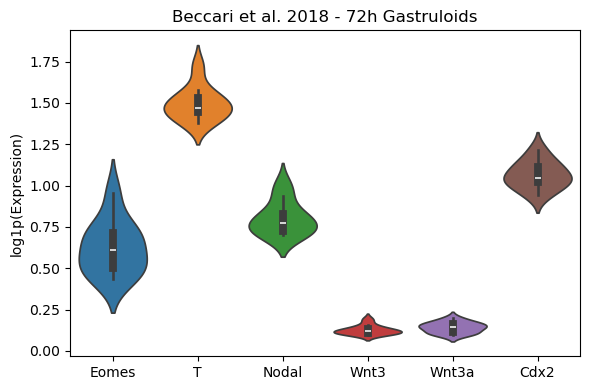

In [6]:
# heatmap
fig,ax=plt.subplots(1,1, figsize=(6,4))

sns.violinplot(data=log_df.loc[['Eomes','T','Nodal','Wnt3','Wnt3a','Cdx2']].T, ax=ax)
ax.set_ylabel("log1p(Expression)")
ax.set_xlabel("")
ax.set_title("Beccari et al. 2018 - 72h Gastruloids")

plt.tight_layout()
plt.savefig("../results/beccari_72h_markers_violinplot.svg", dpi=300)

/tmp/ipykernel_9431/1601617321.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontstyle='italic')


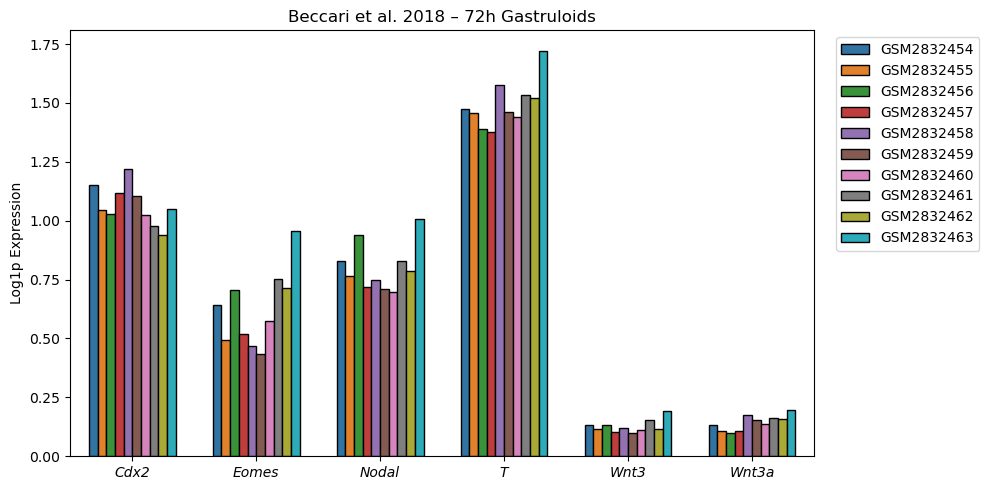

In [7]:
# barplot
plot_df = (
    log_df
    .reset_index()
    .melt(id_vars='name', var_name='Sample', value_name='Expression')
    .rename(columns={'name': 'Gene'})
)


fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=plot_df,
    x="Gene",
    y="Expression",
    hue="Sample",
    ax=ax,
    width=0.7,        # 🔑 smaller width = more space
    edgecolor="black"
)

ax.set_ylabel("Log1p Expression")
ax.set_xlabel("")
ax.set_title("Beccari et al. 2018 – 72h Gastruloids")
ax.set_xticklabels(ax.get_xticklabels(), fontstyle='italic')
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../results/beccari_72h_markers_barplot.svg", dpi=300)
plt.show()


In [8]:
data

sample,GSM2832454,GSM2832455,GSM2832456,GSM2832457,GSM2832458,GSM2832459,GSM2832460,GSM2832461,GSM2832462,GSM2832463
name,,,,,,,,,,
Cdx2,2.156920,1.843690,1.791950,2.054280,2.379990,2.022420,1.782370,1.652800,1.562480,1.854280
Eomes,0.897769,0.637127,1.026180,0.680735,0.596655,0.544181,0.776076,1.119520,1.041100,1.602160
Nodal,1.295470,1.145420,1.557490,1.049980,1.115480,1.035030,1.010810,1.294430,1.196740,1.739530
T,3.369910,3.299420,3.012250,2.960820,3.844690,3.315670,3.226140,3.628700,3.575550,4.596370
Wnt3,0.143052,0.121368,0.142619,0.109212,0.128897,0.103921,0.115695,0.166797,0.121024,0.210035
Wnt3a,0.144066,0.114218,0.102534,0.112818,0.192201,0.164594,0.146328,0.174094,0.171246,0.216674


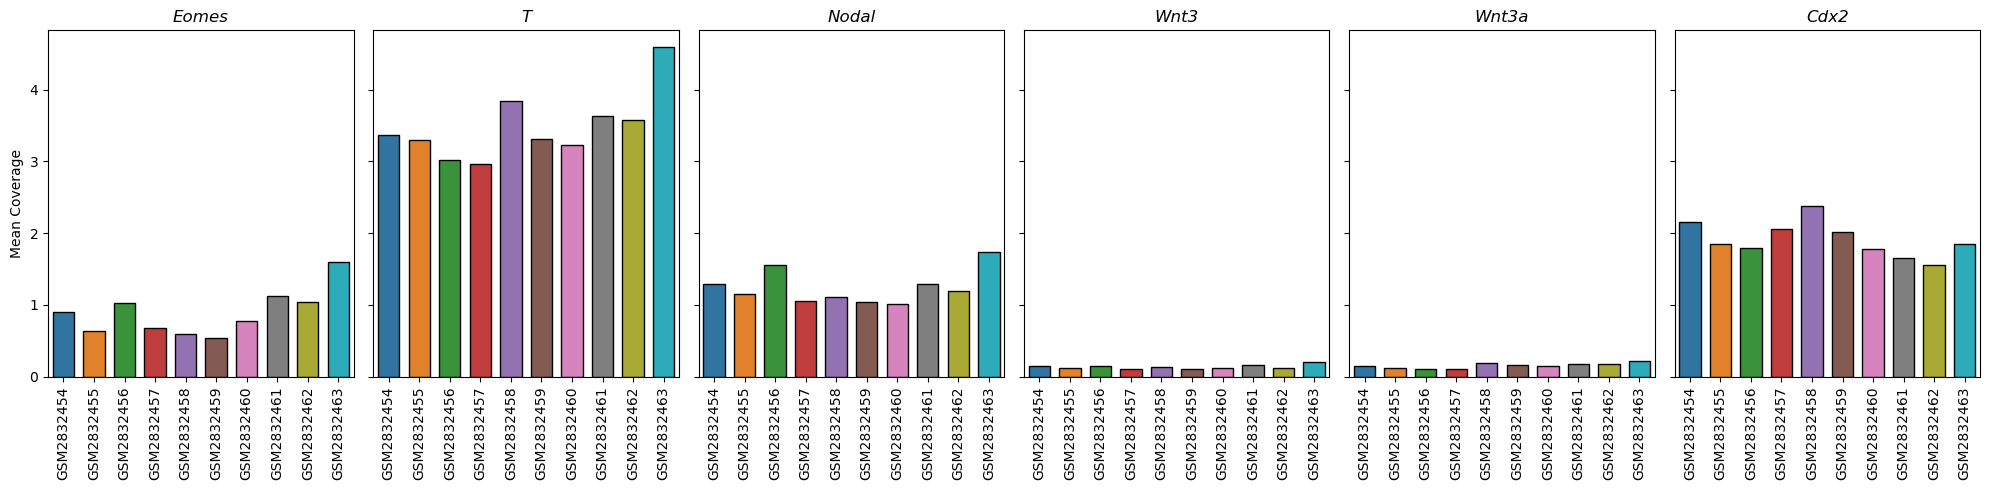

In [13]:
# individual barplots per gene
fig, axes = plt.subplots(1, 6, figsize=(20, 5), sharey=True)

genes = ['Eomes', 'T', 'Nodal', 'Wnt3', 'Wnt3a','Cdx2']

# reshape 
df_long = (
    data
    .reset_index()                # index -> column
    .rename(columns={'name': 'Gene'})
    .melt(id_vars='Gene', var_name='Sample', value_name='Mean Coverage')
)

for gene, ax in zip(genes, axes):
    sns.barplot(
        data=df_long[df_long['Gene'] == gene],
        x="Sample",
        y="Mean Coverage",
        ax=ax,
        hue="Sample",
        width=0.7,
        edgecolor="black"
    )

    ax.set_title(gene, fontstyle='italic')
    ax.set_xlabel("")
    
    if ax == axes[0]:
        ax.set_ylabel("Mean Coverage")
    else:
        ax.set_ylabel("")
    
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("../results/beccari_72h_markers_individual_barplots.svg", dpi=300)
plt.show()

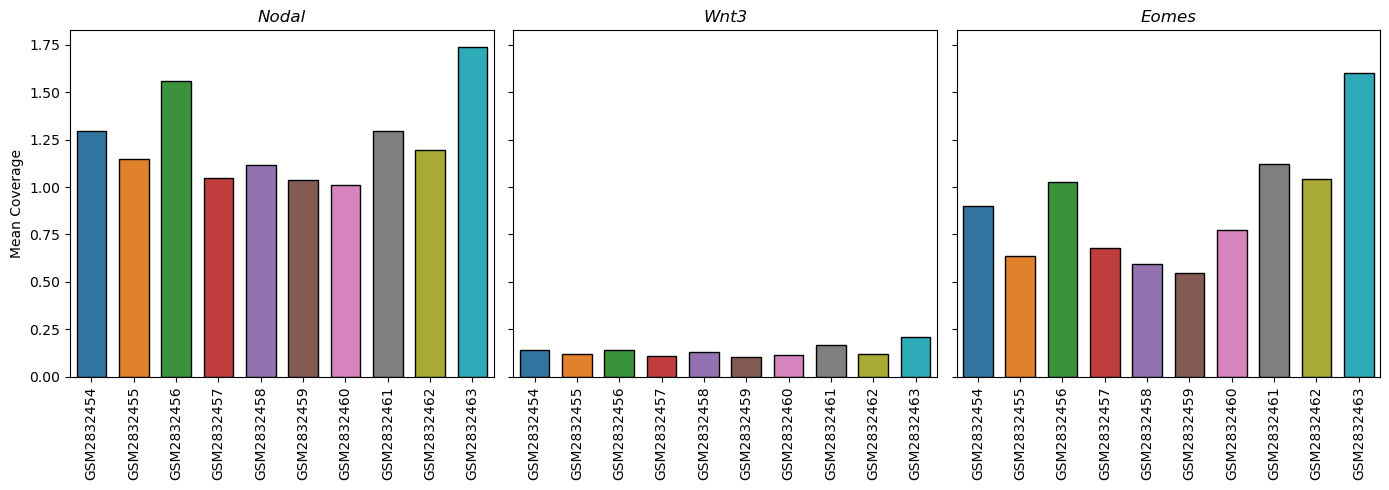

In [17]:
# individual barplots per gene
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

genes = ['Nodal', 'Wnt3', 'Eomes']

# reshape 
df_long = (
    data
    .reset_index()                # index -> column
    .rename(columns={'name': 'Gene'})
    .melt(id_vars='Gene', var_name='Sample', value_name='Mean Coverage')
)

for gene, ax in zip(genes, axes):
    sns.barplot(
        data=df_long[df_long['Gene'] == gene],
        x="Sample",
        y="Mean Coverage",
        ax=ax,
        hue="Sample",
        width=0.7,
        edgecolor="black"
    )

    ax.set_title(gene, fontstyle='italic')
    ax.set_xlabel("")
    
    if ax == axes[0]:
        ax.set_ylabel("Mean Coverage")
    else:
        ax.set_ylabel("")
    
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig("../results/beccari_72h_markers_individual_barplots_subset.svg", dpi=300)
plt.show()

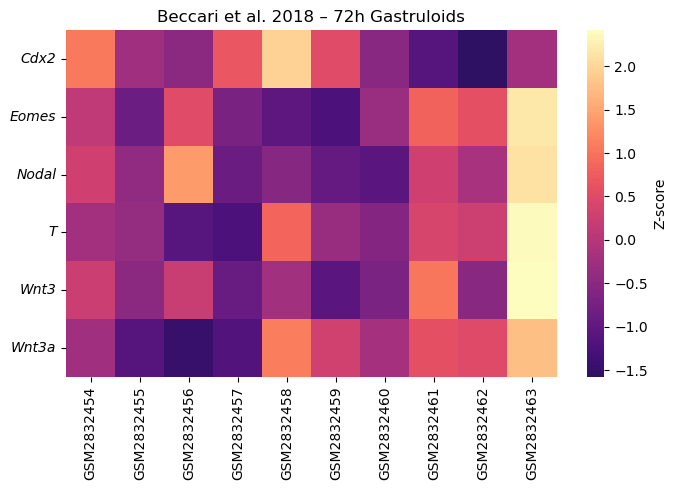

In [12]:
# Z-score per gene (row-wise)
z_df = log_df.apply(zscore, axis=1)

fig, ax = plt.subplots(figsize=(7,5))

sns.heatmap(
    z_df,
    cmap="magma",
    center=0,
    ax=ax,
    cbar_kws={'label': 'Z-score'}
)
ax.set_yticklabels(z_df.index, rotation=0, fontstyle='italic')
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("Beccari et al. 2018 – 72h Gastruloids")

plt.tight_layout()
plt.savefig("../results/beccari_72h_markers_heatmap.svg", dpi=300)
plt.show()

